In [1]:
import numpy as np

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt


%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv(r"C:\Users\elmak\Downloads\archive (1)\listings.csv")

df.drop(
    columns=['scrape_id', 'City', 'Country', 'Timestamp', 'review_scores_value'],
    index=['scrape_id'],
    inplace=True,
    errors='ignore'
)

df_corr = df.corr(numeric_only=True)
df_corr = df_corr.fillna(0)


scaler = StandardScaler()

scaler.fit(df_corr)

scaled_data = scaler.transform(df_corr)

pca = PCA(n_components=2)

pca.fit(scaled_data)

scaled_pca = pca.transform(scaled_data)

scaled_data.shape

(37, 37)

In [2]:
scaled_pca.shape

(37, 2)

In [3]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df_corr.columns,
    index=['PC1', 'PC2']
)

loadings.T.sort_values(by='PC1', key=abs, ascending=False)

,PC1,PC2
availability_365,0.272244,-0.063321
host_id,0.261154,0.003282
availability_90,0.260434,-0.072481
review_scores_accuracy,-0.260400,-0.126731
review_scores_communication,-0.259778,-0.136933
availability_60,0.256123,-0.061508
review_scores_rating,-0.256082,-0.137012
availability_30,0.251110,-0.041811
review_scores_checkin,-0.247151,-0.146167
review_scores_location,-0.231295,-0.112149


In [4]:
loadings.T.sort_values(by='PC2', key=abs, ascending=False)

,PC1,PC2
maximum_minimum_nights,-0.067098,0.322486
minimum_nights_avg_ntm,-0.119117,0.291712
minimum_minimum_nights,-0.119672,0.291135
minimum_nights,-0.120880,0.290108
number_of_reviews_l30d,0.073612,-0.273870
number_of_reviews_ltm,0.076171,-0.264385
reviews_per_month,0.129945,-0.259131
number_of_reviews,0.039651,-0.242843
maximum_nights,-0.149365,0.227765
calculated_host_listings_count_entire_homes,0.123241,0.223964


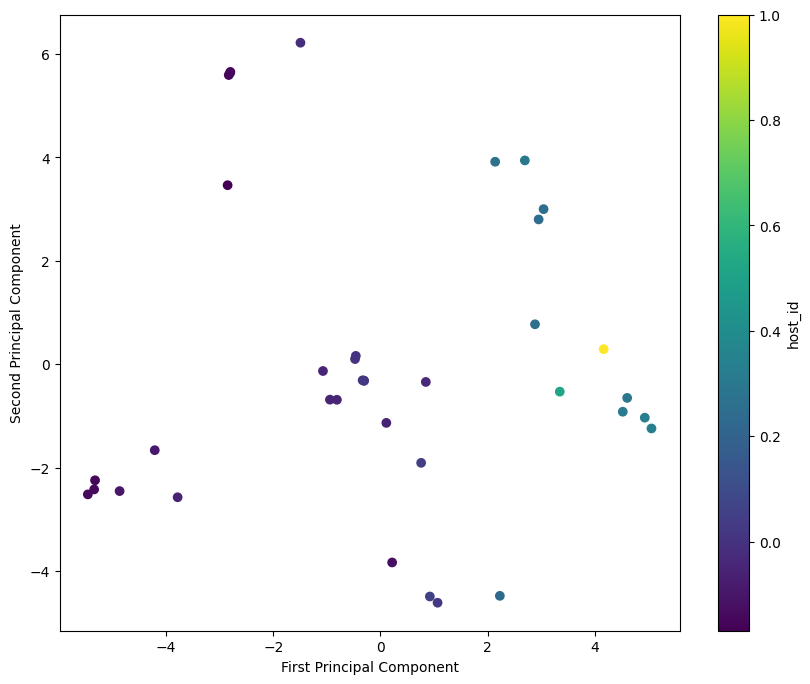

In [13]:
plt.figure(figsize=(10,8))

plt.scatter(
    scaled_pca[:, 0],
    scaled_pca[:, 1],
    c=df_corr['host_id']
)

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.colorbar(label='host_id')
plt.show()

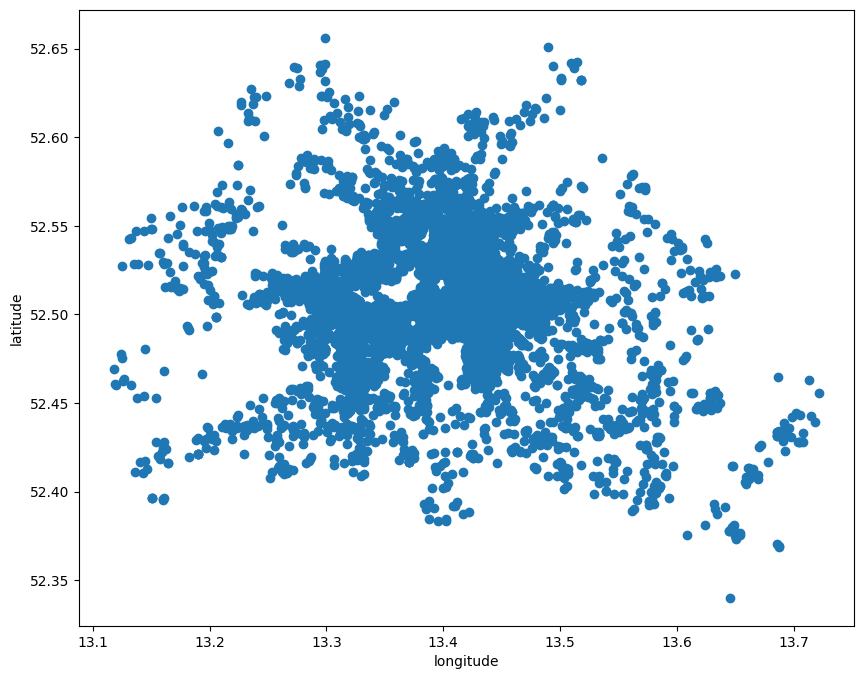

In [16]:
plt.figure(figsize=(10,8))

plt.scatter(df['longitude'], df['latitude'])

plt.xlabel('longitude')
plt.ylabel('latitude')
plt.show()